Train: 16511 | Val: 2064 | Test: 2064


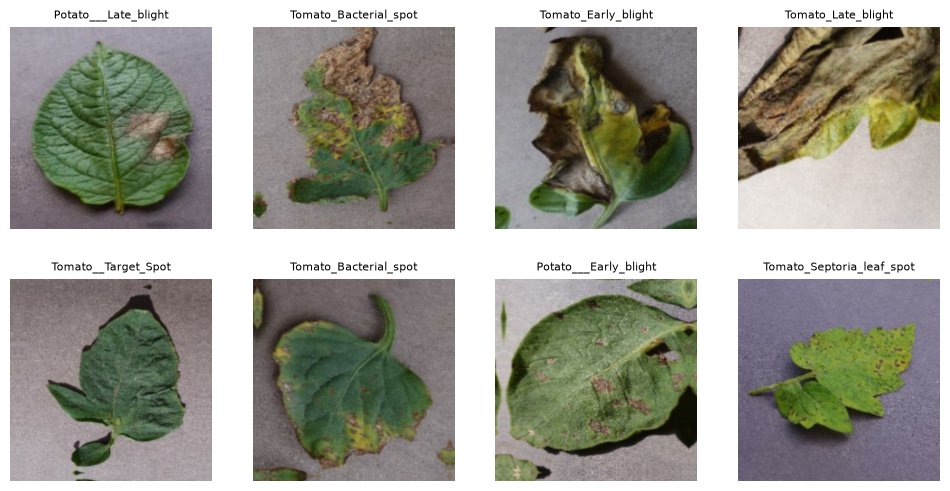

In [1]:
from pathlib import Path
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

DATA_DIR = Path("../data/PlantVillage")
IMG_SIZE = (224, 224)
BATCH = 32
SEED = 42

# 1. Collect every image path and its label
class_names = sorted(p.name for p in DATA_DIR.iterdir() if p.is_dir())
paths, labels = [], []
for i, c in enumerate(class_names):
    for f in (DATA_DIR / c).glob("*"):
        paths.append(str(f))
        labels.append(i)

# 2. Split 80% train / 10% validation / 10% test (stratified)
X_train, X_tmp, y_train, y_tmp = train_test_split(
    paths, labels, test_size=0.2, stratify=labels, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=SEED)
print("Train:", len(X_train), "| Val:", len(X_val), "| Test:", len(X_test))

# 3. Build tf.data pipelines
def load(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, IMG_SIZE)
    return img, label

def make_ds(p, l, training=False):
    ds = tf.data.Dataset.from_tensor_slices((p, l))
    if training:
        ds = ds.shuffle(len(p), seed=SEED)
    ds = ds.map(load, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(X_train, y_train, training=True)
val_ds = make_ds(X_val, y_val)
test_ds = make_ds(X_test, y_test)

# 4. Data augmentation (only applied during training)
augment = keras.Sequential([
    keras.layers.RandomFlip("horizontal_and_vertical"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
])

# 5. Preview augmented images
for images, lbls in train_ds.take(1):
    plt.figure(figsize=(12, 6))
    for i in range(8):
        ax = plt.subplot(2, 4, i + 1)
        aug = augment(images[i:i+1], training=True)[0]
        plt.imshow(aug.numpy().astype("uint8"))
        plt.title(class_names[lbls[i]], fontsize=8)
        plt.axis("off")
    plt.show()